**Un modello di previsione per il mercato immobiliare**

RealEstateAI Solutions si propone di ottimizzare la valutazione dei prezzi immobiliari attraverso l'uso di tecniche avanzate di regolarizzazione in modelli di regressione lineare. L'obiettivo è fornire previsioni di prezzo più accurate e affidabili, riducendo il rischio di overfitting e migliorando la capacità di generalizzazione del modello.

Nel settore immobiliare, ottenere stime precise dei prezzi delle proprietà è cruciale per prendere decisioni informate. Tuttavia, i modelli di regressione lineare tradizionali possono soffrire di overfitting, compromettendo l'accuratezza delle previsioni. È necessario esplorare metodi di regolarizzazione efficaci per migliorare le performance predittive e gestire la complessità del modello.

Implementando e confrontando metodi di regolarizzazione come Lasso, Ridge e Elastic Net, RealEstateAI Solutions offrirà un sistema in grado di fornire previsioni di prezzo immobiliari più accurate e stabili. Questo permetterà agli agenti immobiliari e agli investitori di prendere decisioni basate su dati più affidabili, aumentando la loro competitività nel mercato.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split,KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
#Url al dataset
BASE_URL ='https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv'

In [5]:
#creo il dataframe
df = pd.read_csv(BASE_URL)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


*Preparazione del Dataset*

In [6]:
#verifico il numero di righe e colonne totali
df.shape

(545, 13)

In [7]:
#conto quanti valori mancanti ci sono

df.isna().sum()
#0 valori mancanti
#inoltre il dataset ha le variabili categoriche già ricodificate

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
#guardo la correlazione dei dati
df.corr()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.190086
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.081367
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.097834
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.089418
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,0.043288
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.079403
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.057513
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.093425
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.069076
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,0.020887


In [12]:
random_seed = 42 #imposto il seed

In [9]:
#Setting feature e target

# Applico One-Hot Encoding per la colonna furnishingstatus, per evitare pesi differenti dato i valori possibili 0,1,2
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

X = df_encoded.drop(columns= 'price', axis = 1).values
y = df_encoded["price"]


df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_1,furnishingstatus_2
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False


Skewness: 1.21


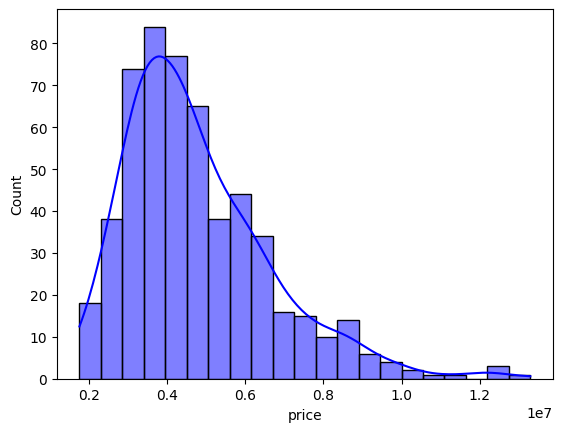


APPLICAZIONE LOGARITMO
Skewness dopo Log: 0.14


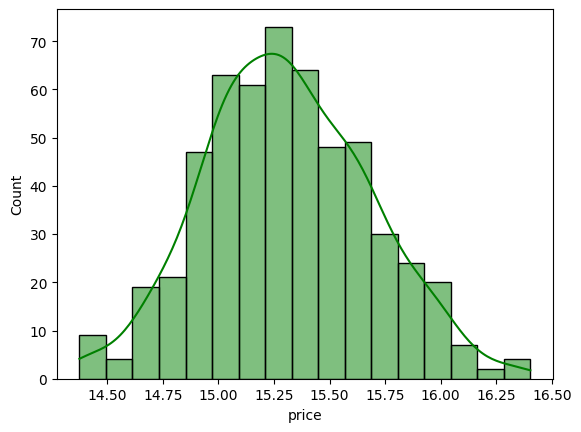

In [28]:
#valuto la distribuzione dei prezzi immobiliari


target = df['price']

# Calcolo la Skewness che mni dice quanto la distribuzione dei prezzi sia asimettrica
print(f"Skewness: {target.skew():.2f}")




# Istogramma con curva di densità
sns.histplot(target, kde=True, color='blue')



plt.show()
#i prezzi non seguono una distribuzione normale come prevedibile. Per applicare modelli come Ridge, Lasso o Elastic Net è meglio ragionare su distribuzioni normali
# Applico la trasformazione logaritmica al target (funzione monotona crescente)
print("\nAPPLICAZIONE LOGARITMO")
target_log = np.log1p(target)
print(f"Skewness dopo Log: {target_log.skew():.2f}")
sns.histplot(target_log, kde=True, color='green')
plt.show()

#La distribuzione post logaritmo diventa una distribuzione molto più normale

In [13]:
#trasformo la mia variabile target in base a quanto visto sopra
#log di y segue una distribuzione più normale
y = np.log1p(y)
#eseguo lo split tra train e test come primo metodo di esame dei modelli
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)


#istanzio la funzione per standardizzare i miei dati
ss = StandardScaler()

x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

# poly = PolynomialFeatures(degree= 3, include_bias = False)

# x_train = poly.fit_transform(x_train)
# x_test = poly.transform(x_test)


*Implementazione Modelli di Regressione*

In [14]:
def coef_complexity(model):
  coef_not_null = np.sum(model.coef_ != 0)
  coef_total = len(model.coef_)

  print(f"Modello con: {coef_not_null} feature attive su {coef_total}")

In [15]:

#definisco la funzione generale che mi valuta il modello in base all'r2 e al MSE
def model_evaluation(model, database):

  x,y = database

  y_pred = model.predict(x)

  print(f"MSE: {mean_squared_error(y, y_pred)}")
  print(f"R2: {r2_score(y,y_pred)}")
  coef_complexity(model)

In [16]:

#definisco il range di alpha su cui voglio testare i miei modelli di regressione (HYPERPARAMETER)
alpha_params = (0.001,0.01, 0.1,1,10)



In [46]:
#Voglio avere visione in output di MSE (con il target trasformato) e R2
#eseguo dei calcoli "rozzi" per verificare i valori in output e avere un feedback sulla qualità dei modelli

for alph in alpha_params:

  #RIDGE
  print(f"MODELLO RIDGE con alpha ={alph}")
  rr = Ridge(alpha= alph, random_state = random_seed)

  rr.fit(x_train,y_train)

  print("TRAIN")
  model_evaluation(rr, (x_train,y_train))

  print("TEST")
  model_evaluation(rr, (x_test,y_test))

  print("\n")
  #Lasso
  print(f"MODELLO LASSO con alpha ={alph}")
  ll = Lasso(alpha= alph, random_state = random_seed)

  ll.fit(x_train,y_train)

  print("TRAIN")
  model_evaluation(ll, (x_train,y_train))

  print("TEST")
  model_evaluation(ll, (x_test,y_test))


  print("\n")
  #Elastic Net
  print(f"MODELLO ELASTIC NET con alpha ={alph}")
  el = ElasticNet(alpha= alph, l1_ratio = 0.5, random_state = random_seed)

  el.fit(x_train,y_train)

  print("TRAIN")
  model_evaluation(el, (x_train,y_train))

  print("TEST")
  model_evaluation(el, (x_test,y_test))

  print("\n")


#Non trovo grandi differenze sui risultati del Ridge al variare di alpha, l'R2 del train sta abbastanza stabile intorno al 0.71, mentre il test intorno a 0.65-0.66.
#invece per Lasso ed ELastic Net  subiscono un drop down dopo che si passa da alpha 0.01

#noto che Ridge non utilizza tutte le feature, non le azzera mai
#Lasso ma anche Elastic Net (con un livello ibrido di 0.5) azzera da alpha = 0.1

#Direi che non sto andando in overfitting dato che non ho un drop drastico di R2 tra train e test

MODELLO RIDGE con alpha =0.001
TRAIN
MSE: 0.0001517480600332586
R2: 0.7048182880320571
Modello con: 13 feature attive su 13
TEST
MSE: 0.00018517243281921427
R2: 0.6544838594878732
Modello con: 13 feature attive su 13


MODELLO LASSO con alpha =0.001
TRAIN
MSE: 0.00015967708353298456
R2: 0.6893946791215366
Modello con: 13 feature attive su 13
TEST
MSE: 0.0001966267751496206
R2: 0.633111022862831
Modello con: 13 feature attive su 13


MODELLO ELASTIC NET con alpha =0.001
TRAIN
MSE: 0.00015374122666329628
R2: 0.7009411621039698
Modello con: 13 feature attive su 13
TEST
MSE: 0.00018846135421003333
R2: 0.6483470095901727
Modello con: 13 feature attive su 13


MODELLO RIDGE con alpha =0.01
TRAIN
MSE: 0.00015174806009921757
R2: 0.7048182879037532
Modello con: 13 feature attive su 13
TEST
MSE: 0.00018517197434551628
R2: 0.6544847149611219
Modello con: 13 feature attive su 13


MODELLO LASSO con alpha =0.01
TRAIN
MSE: 0.0004542921470366745
R2: 0.11630676750340263
Modello con: 2 feature attive s

In [39]:
#Provo a verificare con Kfold con modello ElasticNet sui vari alpha



#dizionario con la media score per alpha
score_alpha  ={}



ss = StandardScaler()

for alph in alpha_params:

  #definisco il modello (Ridge su cui ho ottenuto risultati migliore)
  model = Ridge(alpha= alph, random_state = random_seed)

  train_score = []
  test_score = []


  kF = KFold(n_splits=5, shuffle=True, random_state=random_seed)


  for train_index, test_index in kF.split(X):


    #Eseguo lo split train test di feature e target

    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]


    #standardizzo il tutto secondo la stessa logica


    x_train = ss.fit_transform(x_train)
    x_test = ss.transform(x_test)

    #adotto il modello


    #fitto i dati di train sul test in base al modello scelto
    model.fit(x_train, y_train)




    #calcolo l'r2 per train e test
    train_score.append(r2_score(y_train,model.predict(x_train)))
    test_score.append(r2_score(y_test,model.predict(x_test)))


  #definisco lo score medio per alpha
  print(f"Alpha = {alph}, Train = {np.array(train_score).mean().round(3)}, Test = {np.array(test_score).mean().round(3)}")
  score_alpha[alph] = {'Train': np.array(train_score).mean().round(3), 'Test': np.array(test_score).mean().round(3)}



print(score_alpha)


#K -fold sembra validare i risultati che avevo ottenuto dall'applicazione singola del modello Ridge, ottengo risultati di test e train abbastanza coerenti con quanto ho ottenuto precedentemente


#CONCLUSIONE:
#CON UN DATASET di tale dimensioni (545 osservazioni) non si possono ottenere risultati migliori per il test.

Alpha = 0.001, Train = 0.699, Test = 0.666
Alpha = 0.01, Train = 0.699, Test = 0.666
Alpha = 0.1, Train = 0.699, Test = 0.666
Alpha = 1, Train = 0.699, Test = 0.666
Alpha = 10, Train = 0.699, Test = 0.667
{0.001: {'Train': np.float64(0.699), 'Test': np.float64(0.666)}, 0.01: {'Train': np.float64(0.699), 'Test': np.float64(0.666)}, 0.1: {'Train': np.float64(0.699), 'Test': np.float64(0.666)}, 1: {'Train': np.float64(0.699), 'Test': np.float64(0.666)}, 10: {'Train': np.float64(0.699), 'Test': np.float64(0.667)}}


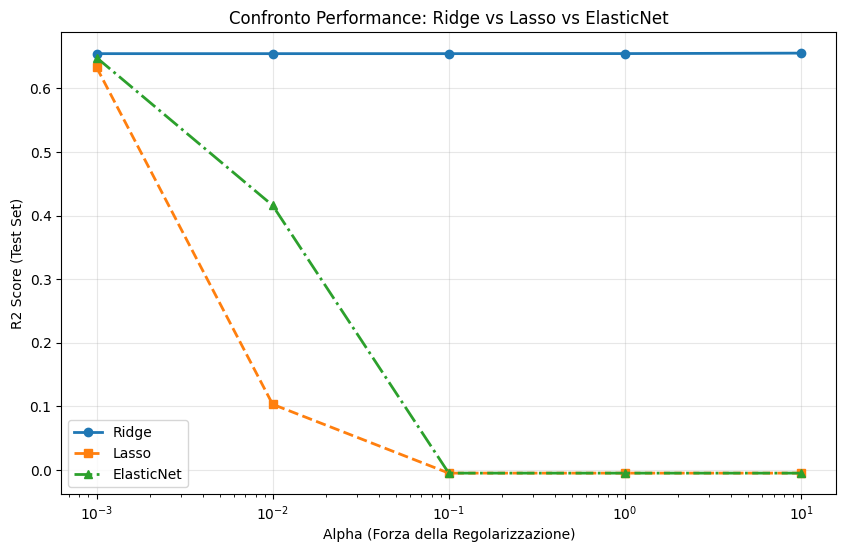

In [34]:
#Visualizzo gli score dei tre metodi al variare di alpha

# Inizializzo le liste per salvare i risultati

scores_ridge = []
scores_lasso = []
scores_enet = []


# Valuto e salvo anche i coefficienti
coefs_lasso = []
coefs_ridge = []
coefs_enet = []

# Riprendo i punteggi per i vari alpha sia per gli score che per i coefficienti
for alph in alpha_params:
    # Ridge
    r = Ridge(alpha=alph, random_state=random_seed)
    r.fit(x_train, y_train)
    scores_ridge.append(r.score(x_test, y_test))
    coefs_ridge.append(r.coef_)

    # Lasso
    l = Lasso(alpha=alph, random_state=random_seed)
    l.fit(x_train, y_train)
    scores_lasso.append(l.score(x_test, y_test))
    coefs_lasso.append(l.coef_)

    # ElasticNet
    e = ElasticNet(alpha=alph, l1_ratio=0.5, random_state=random_seed)
    e.fit(x_train, y_train)
    scores_enet.append(e.score(x_test, y_test))
    coefs_enet.append(e.coef_)

# 3. Crea il Grafico Comparativo
plt.figure(figsize=(10, 6))

plt.plot(alpha_params, scores_ridge, label='Ridge', marker='o', linestyle='-', linewidth=2)
plt.plot(alpha_params, scores_lasso, label='Lasso', marker='s', linestyle='--', linewidth=2)
plt.plot(alpha_params, scores_enet, label='ElasticNet', marker='^', linestyle='-.', linewidth=2)

plt.xscale('log') #  per vedere bene gli ordini di grandezza
plt.xlabel('Alpha (Forza della Regolarizzazione)')
plt.ylabel('R2 Score (Test Set)')
plt.title('Confronto Performance: Ridge vs Lasso vs ElasticNet')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#Conferma visiva degli output precedenti. Ridge rimane stabile, gli altri due modelli crollano

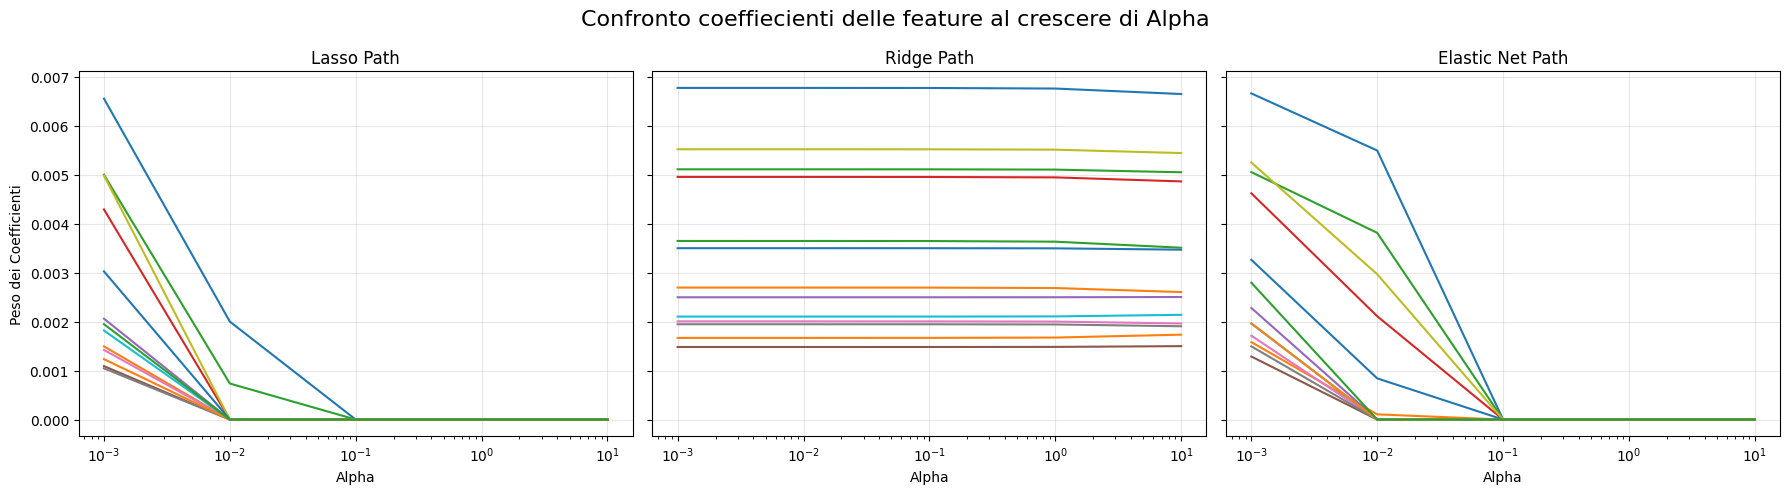

In [38]:
#Voglio avere visibilità dei coefficienti al variare di alpha in un grafico

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Creo un dizionario per ciclare sui modelli
models_data = {
    "Lasso": coefs_lasso,
    "Ridge": coefs_ridge,
    "Elastic Net": coefs_enet
}

# 3. Ciclo unico usando enumerate su keys() e values()
for i, (model_name, coefs) in enumerate(models_data.items()):

    # Plotto i dati CORRENTI (coefs) sull'asse CORRENTE (ax[i])
    ax[i].plot(alpha_params, coefs)

    # Impostazioni specifiche per ogni asse
    ax[i].set_xscale('log') # Scala logaritmica
    ax[i].set_title(f'{model_name} Path') # Titolo dinamico
    ax[i].set_xlabel('Alpha')
    ax[i].grid(True, alpha=0.3)

    # Metto l'etichetta asse Y solo sul primo grafico per pulizia
    if i == 0:
        ax[i].set_ylabel('Peso dei Coefficienti')

# Titolo generale
plt.suptitle('Confronto coeffiecienti delle feature al crescere di Alpha', fontsize=16)

# Ottimizza gli spazi per non far sovrapporre le scritte
plt.tight_layout()

# Mostra tutto alla fine
plt.show()

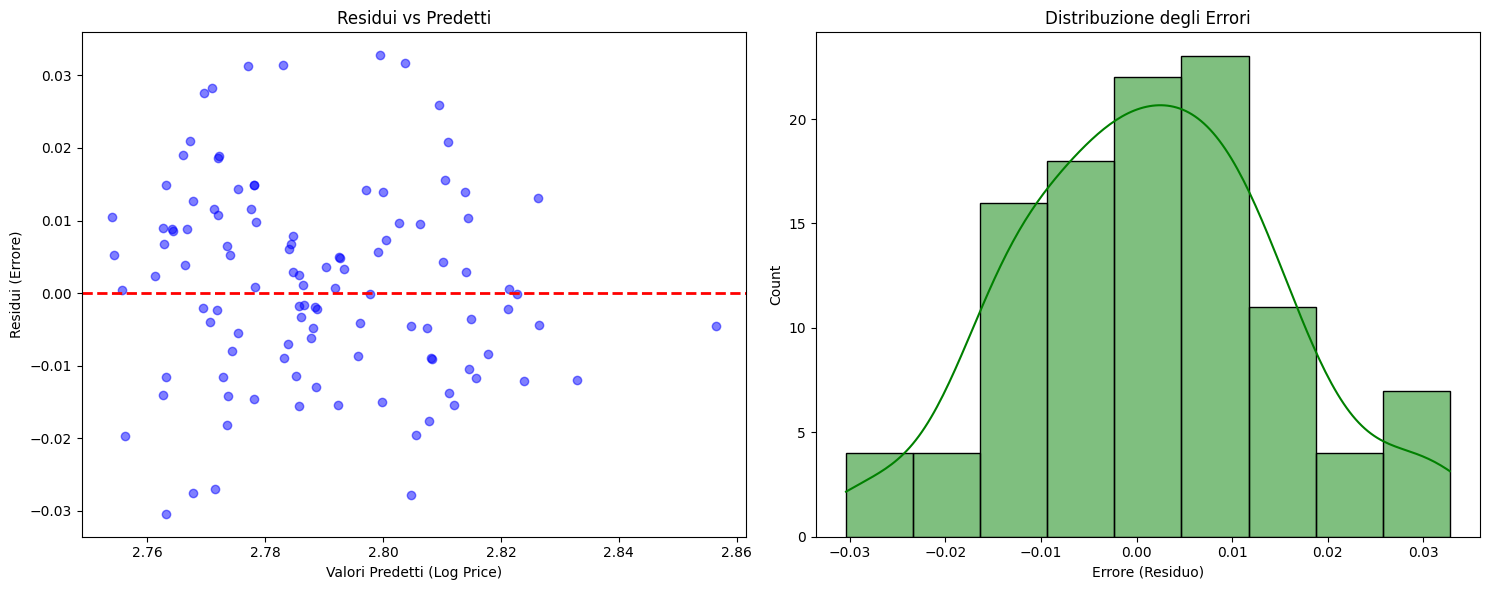

In [40]:


# Scelgo uno dei ridge che hanno dato il risultato migliroe
best_model = Ridge(alpha=0.1, random_state=random_seed)
best_model.fit(x_train, y_train)

# Rieseguo le predizioni
y_pred = best_model.predict(x_test)
residui = y_test - y_pred

# Plot Combinato
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# GRAFICO A: Residui vs Predetti
ax[0].scatter(y_pred, residui, alpha=0.5, color='blue')
ax[0].axhline(0, color='red', linestyle='--', linewidth=2)
ax[0].set_xlabel('Valori Predetti (Log Price)')
ax[0].set_ylabel('Residui (Errore)')
ax[0].set_title('Residui vs Predetti')

# GRAFICO B: Distribuzione dei Residui
sns.histplot(residui, kde=True, ax=ax[1], color='green')
ax[1].set_xlabel('Errore (Residuo)')
ax[1].set_title('Distribuzione degli Errori')

plt.tight_layout()
plt.show()

#Dai risultati ottengo una situazione piacevole:
#dal grafico 1 vedo una nuvola di residui che si distribuisce attorno a 0 quindi direi che il modello ha catturato il trend generale (unbiased)
#inoltre la distribuzione degli errori segue una forma normale centrata quindi direi che l'errore sistematico del modello è quasi azzerato

In [52]:


# Verifico quali sono le feature più importanti per il modello migliore

XX = df_encoded.drop(columns= 'price', axis = 1)
feature_names = XX.columns

#creo una series dei coefficiente per il modello migliore
coefs = pd.Series(best_model.coef_, index=feature_names)


top_3_features = coefs.abs().sort_values(ascending=False).head(3)

#Recupero i valori originali (con il segno + o -) per queste 3 feature
top_3_original = coefs[top_3_features.index]

print("LE 3 FEATURE REGINE")
print(top_3_original)

LE 3 FEATURE REGINE
area               0.006768
airconditioning    0.005516
bathrooms          0.005107
dtype: float64


**CONCLUSIONI**

L'analisi dei modelli di regressione regolarizzata (Ridge, Lasso, ElasticNet) ha identificato un limite di performance predittiva con un $R^2$ massimo di circa 0.65 sul Test Set.

Nonostante l'ottimizzazione degli iperparametri (Alpha) e il preprocessing avanzato (One-Hot Encoding e trasformazione logaritmica del target), i modelli lineari hanno raggiunto il loro massimo. L'analisi dei residui ha mostrato una distribuzione tendenzialmente normale (garantendo l'affidabilità statistica delle stime), ma la presenza di residui strutturati evidenzia in modo chiaro che la relazione tra le caratteristiche della casa e il prezzo non è puramente lineare. Il valore di una casa non è semplicemente la somma delle sue parti, ma include interazioni complesse che un modello lineare fatica a catturare

Per quanto riguarda i modelli utilizzati quello che si può dire è che Lasso è stato utile per identificare le feature più forti, azzerando i coefficienti delle variabili irrilevanti.

Ridge ha mantenuto stabili le performance distribuendo il peso tra variabili correlate. Il fatto che i punteggi di Train e Test siano vicini conferma che l'Overfitting è praticamente nullo: il modello generalizza bene, ma è limitato dall'Underfitting strutturale.

Con Elastic Net non si sono evidenziate grosse differenza con un livello ibrido bilanciato (0.5) e neanche su prove singole al variare del ratio.

Emerge che le variabili dominanti sono la metratura (Area), Airconditioning e il numero di Bagni. Questo fa capire che per apprezzare l'immobile l'agenzia immobiliare dovrebbe puntare (esclusa la ovvia area dell'immobile) all'aumento dei servizi e aria condizionata.